<a href="https://colab.research.google.com/github/simransimran20704-cloud/GuessTheNumber-CPP/blob/main/FER2013_CNN_Emotion_Recognition_Project_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="
background:linear-gradient(to right,#4F46E5,#2563EB);
padding:18px;
border-radius:10px;
text-align:center;
color:white;">

<h1 style="margin:0;">😊 DeepFER: Facial Emotion Recognition Using Deep Learning</h1>

<h3 style="margin-top:8px;">
Dataset Exploration & Exploratory Data Analysis (EDA)
</h3>

</div>

<div style="
background-color:#EEF4FF;
padding:15px;
border-left:6px solid #2563EB;
border-radius:8px;">

<h3 style="color:#1E3A8A; margin-top:0;">
🎯 Objective
</h3>

<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

The objective of this notebook is to understand the facial emotion dataset before training a deep learning model. We will explore the dataset structure, visualize sample images, analyze class distribution, and perform basic exploratory data analysis.

</div>

</div>

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
📚 Import Required Libraries
</h2>

<p>
<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

The following libraries are required for dataset handling, image processing, visualization, and numerical computations.

</p>
</div>
</div>

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image

<div style="
background:#ECFDF5;
padding:15px;
border-left:6px solid #10B981;
border-radius:8px;">

<h3 style="color:#047857; margin-top:0;">
📝 Library Description
</h3>

<div style="
color:#1F2937;
font-size:15px;
line-height:1.8;">

<ul>
<li><b>os</b> – Used to access folders and files from the dataset.</li>

<li><b>random</b> – Selects random images for visualization.</li>

<li><b>NumPy</b> – Performs numerical operations and array manipulation.</li>

<li><b>Matplotlib</b> – Displays images and creates visualizations.</li>

<li><b>PIL (Python Imaging Library)</b> – Opens and processes image files.</li>
</ul>

</div>

</div>

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
📂 Dataset Information
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

<b>Dataset Name:</b> FER2013 (Facial Emotion Recognition 2013)
<br><br>

<b>Source:</b> Kaggle
<br><br>

<b>Dataset Link:</b><br>
https://www.kaggle.com/datasets/msambare/fer2013
<br><br>

<b>Image Size:</b> 48 × 48 Pixels
<br><br>

<b>Image Type:</b> Grayscale
<br><br>

<b>Number of Emotion Classes:</b> 7
<ul>
<li>Angry</li>
<li>Disgust</li>
<li>Fear</li>
<li>Happy</li>
<li>Neutral</li>
<li>Sad</li>
<li>Surprise</li>
</ul>

<b>Description:</b><br>
The FER2013 dataset contains grayscale facial images of different human emotions. The images are organized into separate <b>train</b> and <b>test</b> folders and are used to train and evaluate the Convolutional Neural Network (CNN) model for facial emotion recognition.

</div>

</div>

<div style="
background:#FFF7ED;
padding:15px;
border-left:6px solid #EA580C;
border-radius:8px;">

<h2 style="color:#C2410C; margin-top:0;">
📂 Dataset Path
</h2>

<div style="
color:#1F2937;
font-size:15px;
line-height:1.8;">

In this step, we specify the paths to the training and testing datasets. These directories contain facial images organized into different emotion categories, which will be used for training and evaluating the deep learning model.

</div>

</div>

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The FER2013 dataset was downloaded from Kaggle and extracted into the project directory. The dataset contains separate <b>train</b> and <b>test</b> folders, which are used to load images for training and evaluation of the CNN model.

</div>

</div>

In [2]:
train_path = "/content/archive-3/train"
test_path = "/content/archive-3/test"

print("Training Path:", train_path)
print("Testing Path:", test_path)

Training Path: /content/archive-3/train
Testing Path: /content/archive-3/test


<div style="
background:#ECFDF5;
padding:15px;
border-left:6px solid #10B981;
border-radius:8px;">

<h3 style="color:#047857; margin-top:0;">
✅ Observation
</h3>

<div style="
color:#1F2937;
font-size:15px;
line-height:1.8;">

The dataset is organized into two separate folders: one for training and another for testing. Each folder contains subfolders representing different facial emotion classes.

</div>

</div>

In [3]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import zipfile

zip_path = "/content/drive/MyDrive/archive-3.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

In [6]:
import os

print(os.listdir('/content/archive-3'))

['test', 'train']


<div style="
background:#EFF6FF;
padding:15px;
border-left:6px solid #2563EB;
border-radius:8px;">

<h2 style="color:#1E40AF; margin-top:0;">
📂 Display Emotion Classes
</h2>

<div style="
color:#1F2937;
font-size:15px;
line-height:1.8;">

In this step, we retrieve all the emotion categories available in the training dataset. Each folder inside the training directory represents a unique facial emotion class that will be used for model training.

</div>

</div>

In [7]:
import os

train_path = "/content/archive-3/train"
test_path = "/content/archive-3/test"

emotion_classes = os.listdir(train_path)

print("Emotion Classes:")
for i, emotion in enumerate(emotion_classes, 1):
    print(f"{i}. {emotion}")

Emotion Classes:
1. neutral
2. sad
3. surprise
4. fear
5. angry
6. disgust
7. happy


<div style="
background:#FFF7ED;
padding:15px;
border-left:6px solid #EA580C;
border-radius:8px;">

<h2 style="color:#C2410C; margin-top:0;">
📊 Number of Images in Each Emotion Class
</h2>

<div style="
color:#1F2937;
font-size:15px;
line-height:1.8;">

This section calculates the number of images available in each emotion category of the training dataset. It helps us understand the distribution of samples across different classes before training the deep learning model.

</div>

</div>

In [8]:


train_path = r"/content/archive-3/train"
test_path = r"/content/archive-3/test"

def count_images(path):
    count = 0
    for root, dirs, files in os.walk(path):
        count += len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    return count

train_count = count_images(train_path)
test_count = count_images(test_path)

print("Total Training Images:", train_count)
print("Total Testing Images:", test_count)
print("Total Images:", train_count + test_count)

Total Training Images: 28709
Total Testing Images: 7178
Total Images: 35887


In [9]:

train_path = r"/content/archive-3/train"

class_counts = {}

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        class_counts[class_name] = count

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

print("Total Classes:", len(class_counts))

neutral: 4965
sad: 4830
surprise: 3171
fear: 4097
angry: 3995
disgust: 436
happy: 7215
Total Classes: 7


<div style="
background:#ECFDF5;
padding:15px;
border-left:6px solid #10B981;
border-radius:8px;">

<h3 style="color:#047857; margin-top:0;">
✅ Observation
</h3>

<div style="
color:#1F2937;
font-size:15px;
line-height:1.8;">

The training dataset contains images from seven different emotion categories. The number of images in each class may vary, which can influence the model's learning performance during training.

</div>

</div>


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
📏 Image Dimension Analysis
</h2>

<p>
<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

Image dimension analysis is performed to understand the size and resolution of images present in the dataset.
This helps in checking whether all images have consistent dimensions before applying deep learning models.

</p>
</div>
</div>

In [10]:

train_path = r"/content/archive-3/train"

widths = []
heights = []

for emotion in os.listdir(train_path):
    emotion_path = os.path.join(train_path, emotion)

    for img_name in os.listdir(emotion_path):
        img_path = os.path.join(emotion_path, img_name)

        try:
            img = Image.open(img_path)
            widths.append(img.size[0])
            heights.append(img.size[1])
        except:
            pass

print("Unique Widths:", set(widths))
print("Unique Heights:", set(heights))
print("Total Images Checked:", len(widths))

Unique Widths: {48}
Unique Heights: {48}
Total Images Checked: 28709


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
🎨 Pixel Intensity Distribution Analysis
</h2>

<p>
<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

Pixel intensity analysis helps to understand the distribution of grayscale pixel values in facial images.
It provides insights about image brightness, contrast, and variations present in the dataset.

</p>
</div>
</div>

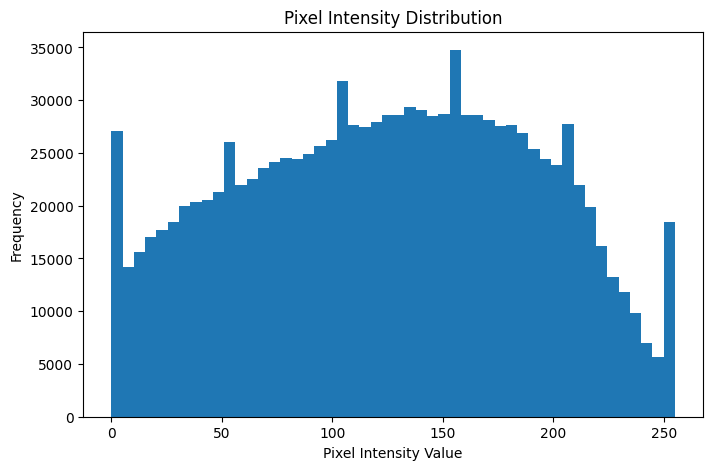

In [11]:

train_path = r"/content/archive-3/train"

pixels = []

count = 0

for emotion in os.listdir(train_path):
    emotion_path = os.path.join(train_path, emotion)

    for img_name in os.listdir(emotion_path):
        img_path = os.path.join(emotion_path, img_name)

        img = Image.open(img_path).convert('L')
        pixels.extend(np.array(img).flatten())

        count += 1

        if count == 500:
            break

    if count == 500:
        break

plt.figure(figsize=(8,5))
plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity Value")
plt.ylabel("Frequency")
plt.show()

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
🖼️ Sample Image Visualization
</h2>

<p>
<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

Sample images from different emotion classes are visualized to understand facial expression patterns and variations present in the dataset.
This helps in getting a better understanding of image quality, facial features, and emotion categories.

</p>
</div>
</div>

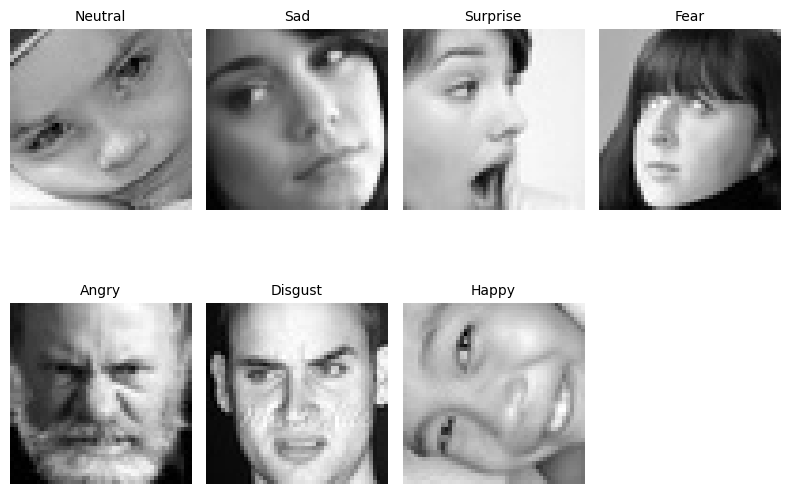

In [12]:

train_path = r"/content/archive-3/train"

classes = os.listdir(train_path)

plt.figure(figsize=(8,6))

for i, emotion in enumerate(classes):
    emotion_path = os.path.join(train_path, emotion)

    image_name = os.listdir(emotion_path)[0]
    image_path = os.path.join(emotion_path, image_name)

    img = Image.open(image_path)

    plt.subplot(2,4,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(emotion.capitalize(), fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

<div style="
background:#FEF3C7;
padding:15px;
border-left:6px solid #D97706;
border-radius:8px;">

<h2 style="color:#92400E; margin-top:0;">
⚠️ Fix Note
</h2>

<div style="
color:#1F2937;
font-size:15px;
line-height:1.8;">

The original notebook manually loaded every image into a NumPy array, normalized it, label-encoded it, reshaped it, and split it into train/validation sets — but this data was <b>never actually used</b> for training. The real training below uses <code>ImageDataGenerator.flow_from_directory()</code>, which loads images in batches directly from disk. Keeping both pipelines wastes RAM and was a source of confusion, so the unused manual pipeline has been removed. The data loading for training now happens in one place, right before the CNN is built.

</div>

</div>


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
🧠 CNN Model Building
</h2>

<p>
<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

A Convolutional Neural Network (CNN) model is created to learn facial features and classify images into different emotion categories.
CNN layers help in extracting important patterns such as edges, textures, and facial expressions from input images.

</p>
</div>
</div>

In [13]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
📥 Data Generators (Train / Validation)
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

Training and validation data are loaded directly from disk using <code>ImageDataGenerator</code>. Data augmentation (rotation, shifting, zoom, horizontal flip) is applied only to the training set to help the model generalize better and reduce overfitting. The <b>same</b> generator built from the test folder (<code>val_generator</code>) is used both for validation during training and for final evaluation, so there is no risk of accidentally using a stale or mismatched generator later in the notebook.

</div>

</div>


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path = "/content/archive-3/train"
test_path = "/content/archive-3/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical",
    shuffle=True
)

# shuffle=False is important here: it keeps image order aligned with
# val_generator.classes, which is required for the confusion matrix /
# classification report / actual-vs-predicted comparisons later.
val_generator = val_datagen.flow_from_directory(
    test_path,
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("Class indices:", train_generator.class_indices)


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [15]:
import tensorflow as tf

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [16]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [17]:
print(tf.keras.__version__)

3.13.2


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
🧠 CNN Architecture (Improved)
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The original model had only 3 convolution blocks and a single Dense(128) layer, which limited how much it could learn from FER2013 (a genuinely hard, low-resolution, noisy-label dataset). This version adds:
<ul>
<li>A 4th convolution block (256 filters) for richer feature extraction</li>
<li>An extra Conv2D per block (32→32, 64→64, 128→128) so the network learns more before each downsampling</li>
<li>Dropout after every pooling layer (not just at the end) to reduce overfitting</li>
<li><code>padding='same'</code> so spatial information isn't lost too quickly</li>
</ul>

</div>

</div>


In [18]:
model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))

# Block 4
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))

# Classifier head
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output Layer (7 emotions)
model.add(Dense(7, activation='softmax'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,177,319 (4.49 MB)

 Trainable params: 1,175,399 (4.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
📊 CNN Model Summary Observation
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The updated network has four convolution blocks (32→32, 64→64, 128→128, 256) followed by a dense classifier head, with Dropout and Batch Normalization throughout to control overfitting on this relatively small, noisy dataset.

</div>

</div>


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
⚙️ Model Compilation
</h2>

</div>

In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


<h2 style="color:#166534;">
🚀 Model Training
</h2>

In [20]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)


{0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_fer2013_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)


In [22]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=60,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights
)


Epoch 1/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.1661 - loss: 2.5351
Epoch 1: val_accuracy improved from None to 0.25996, saving model to best_fer2013_model.h5



Epoch 1: finished saving model to best_fer2013_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 60s 99ms/step - accuracy: 0.1778 - loss: 2.2792 - val_accuracy: 0.2600 - val_loss: 1.8527 - learning_rate: 0.0010
Epoch 2/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.2101 - loss: 1.9688
Epoch 2: val_accuracy improved from 0.25996 to 0.31527, saving model to best_fer2013_model.h5



Epoch 2: finished saving model to best_fer2013_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.2252 - loss: 1.9107 - val_accuracy: 0.3153 - val_loss: 1.8254 - learning_rate: 0.0010
Epoch 3/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2601 - loss: 1.8215
Epoch 3: val_accuracy improved from 0.31527 to 0.33853, saving model to best_fer2013_model.h5



Epoch 3: finished saving model to best_fer2013_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.2802 - loss: 1.7990 - val_accuracy: 0.3385 - val_loss: 1.7049 - learning_rate: 0.0010
Epoch 4/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3051 - loss: 1.7388
Epoch 4: val_accuracy improved from 0.33853 to 0.34620, saving model to best_fer2013_model.h5



Epoch 4: finished saving model to best_fer2013_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 33s 74ms/step - accuracy: 0.3137 - loss: 1.7343 - val_accuracy: 0.3462 - val_loss: 1.7088 - learning_rate: 0.0010
Epoch 5/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3527 - loss: 1.6464
Epoch 5: val_accuracy improved from 0.34620 to 0.43494, saving model to best_fer2013_model.h5


...


Epoch 39: finished saving model to best_fer2013_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.5937 - loss: 1.0262 - val_accuracy: 0.6234 - val_loss: 1.0038 - learning_rate: 4.0000e-05
Epoch 40/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5995 - loss: 1.0165
Epoch 40: val_accuracy improved from 0.62343 to 0.62580, saving model to best_fer2013_model.h5



Epoch 40: finished saving model to best_fer2013_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.5918 - loss: 1.0317 - val_accuracy: 0.6258 - val_loss: 0.9966 - learning_rate: 4.0000e-05
Epoch 41/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5900 - loss: 1.0166
Epoch 41: val_accuracy did not improve from 0.62580
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.5916 - loss: 1.0173 - val_accuracy: 0.6234 - val_loss: 1.0007 - learning_rate: 4.0000e-05
Epoch 42/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5911 - loss: 1.0239
Epoch 42: val_accuracy did not improve from 0.62580
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.5928 - loss: 1.0185 - val_accuracy: 0.6252 - val_loss: 0.9986 - learning_rate: 4.0000e-05
Epoch 43/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5933 - loss: 1.0164
Epoch 43: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.

Epoch 43: val_accuracy improved from 0.62580 to 0.62594


Epoch 43: finished saving model to best_fer2013_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.5956 - loss: 1.0157 - val_accuracy: 0.6259 - val_loss: 0.9990 - learning_rate: 4.0000e-05
Epoch 44/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5966 - loss: 1.0180
Epoch 44: val_accuracy did not improve from 0.62594
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.5948 - loss: 1.0226 - val_accuracy: 0.6250 - val_loss: 1.0004 - learning_rate: 8.0000e-06
Epoch 45/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5970 - loss: 1.0276
Epoch 45: val_accuracy did not improve from 0.62594
449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.5953 - loss: 1.0109 - val_accuracy: 0.6259 - val_loss: 1.0012 - learning_rate: 8.0000e-06
Epoch 46/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5935 - loss: 1.0211
Epoch 46: ReduceLROnPlateau reducing learning rate to 1.6000001778593287e-06.

Epoch 46: val_accuracy did not improve from 0.62594
44


Epoch 47: finished saving model to best_fer2013_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 61ms/step - accuracy: 0.5957 - loss: 1.0214 - val_accuracy: 0.6268 - val_loss: 0.9988 - learning_rate: 1.6000e-06
Epoch 48/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5904 - loss: 1.0199
Epoch 48: val_accuracy improved from 0.62678 to 0.62761, saving model to best_fer2013_model.h5



Epoch 48: finished saving model to best_fer2013_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.5900 - loss: 1.0172 - val_accuracy: 0.6276 - val_loss: 0.9989 - learning_rate: 1.6000e-06
Epoch 49/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5904 - loss: 1.0061
Epoch 49: ReduceLROnPlateau reducing learning rate to 1e-06.

Epoch 49: val_accuracy did not improve from 0.62761
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.5942 - loss: 1.0155 - val_accuracy: 0.6265 - val_loss: 0.9998 - learning_rate: 1.6000e-06
Epoch 50/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5924 - loss: 1.0246
Epoch 50: val_accuracy did not improve from 0.62761
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.5934 - loss: 1.0218 - val_accuracy: 0.6264 - val_loss: 0.9996 - learning_rate: 1.0000e-06
Epoch 51/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5953 - loss: 1.0245
Epoch 51: val_accuracy did not improve from 0.62761
449/449 ━━━━━━━━━━━

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
📊 Model Performance Visualization
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The performance of the CNN model is analyzed using training and validation accuracy and loss graphs. These graphs help evaluate how well the model learns during training and whether it is overfitting or underfitting.

</div>

</div>

<h3 style="color:#166534;">
📈 Training vs Validation Accuracy Curve
</h3>

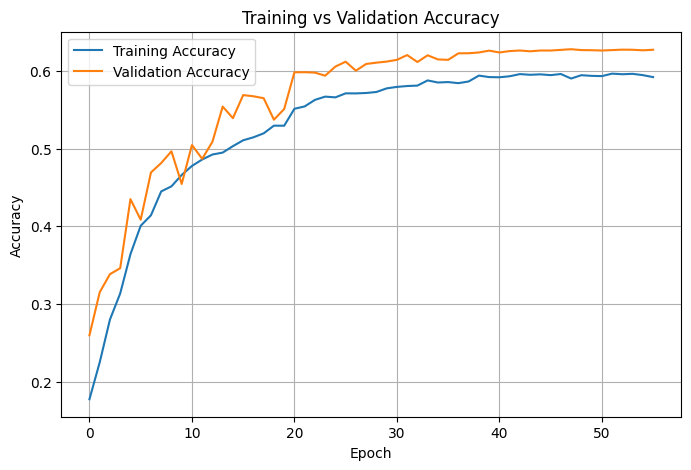

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
📈 Accuracy Observation
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The training accuracy increased steadily with each epoch, indicating that the CNN model successfully learned facial features from the training dataset. The validation accuracy also improved, showing that the model generalized reasonably well on unseen data.

</div>

</div>

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #2563EB;
border-radius:8px;">

<h2 style="color:#1E40AF;">
📉 Training vs Validation Loss Curve
</h2>

</div>

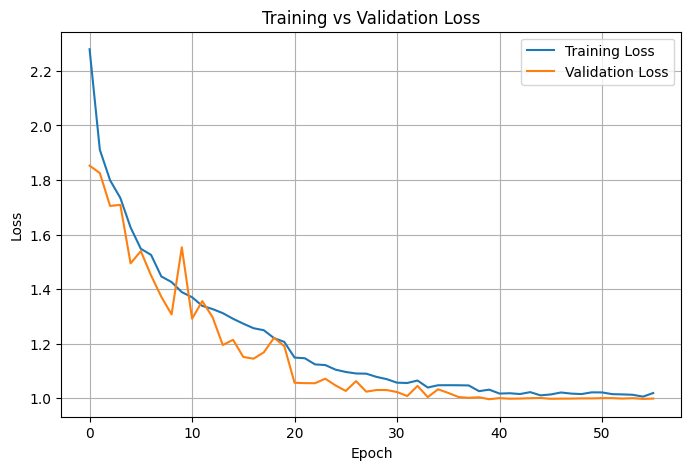

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #2563EB;
border-radius:8px;">

<h2 style="color:#1E40AF;">
📉 Loss Observation
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The training loss decreased consistently during the training process, showing that the model's prediction errors reduced over time. The validation loss also followed a similar trend, indicating stable learning and better optimization of the CNN model.

</div>

</div>

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #9333EA;
border-radius:8px;">

<h2 style="color:#6B21A8;">
🎯 Model Evaluation
</h2>

</div>

In [25]:
test_loss, test_accuracy = model.evaluate(val_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)


113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6276 - loss: 0.9989
Test Accuracy: 0.6276121735572815
Test Loss: 0.9989252090454102


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #F59E0B;
border-radius:8px;">

<h2 style="color:#92400E;">
🔍 Confusion Matrix Analysis
</h2>

</div>

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


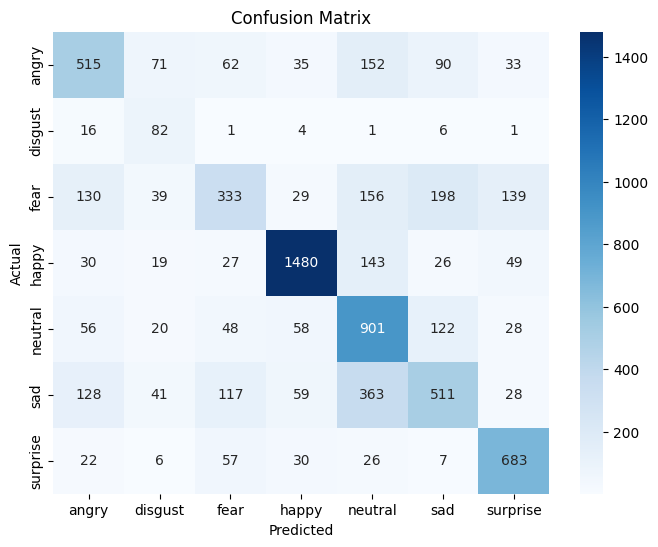

In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Reset generator so we start reading from the first batch again
val_generator.reset()

y_pred_probs = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #F59E0B;
border-radius:8px;">

<h2 style="color:#92400E;">
🔍 Confusion Matrix Observation
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The confusion matrix shows the relationship between actual and predicted emotion classes. The diagonal values represent correctly classified images, while the off-diagonal values represent misclassifications. The model performs well for clearly distinguishable emotions but faces difficulty in separating emotions with similar facial patterns.

</div>

</div>

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #DC2626;
border-radius:8px;">

<h2 style="color:#991B1B;">
📊 Classification Report Observation
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The classification report provides precision, recall, and F1-score for each emotion category. These metrics help in understanding the individual performance of the model for different facial expressions.

</div>

</div>

In [27]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
)

print(report)


              precision    recall  f1-score   support

       angry       0.57      0.54      0.56       958
     disgust       0.29      0.74      0.42       111
        fear       0.52      0.33      0.40      1024
       happy       0.87      0.83      0.85      1774
     neutral       0.52      0.73      0.61      1233
         sad       0.53      0.41      0.46      1247
    surprise       0.71      0.82      0.76       831

    accuracy                           0.63      7178
   macro avg       0.57      0.63      0.58      7178
weighted avg       0.63      0.63      0.62      7178



<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #9333EA;
border-radius:8px;">

<h2 style="color:#6B21A8;">
📋 Classification Report Observation
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The classification report evaluates the model performance using precision, recall, and F1-score for each emotion category. The results provide detailed information about how accurately the CNN model identifies individual emotions. A higher F1-score indicates better balance between correct predictions and detection capability.

</div>

</div>

<h2 style="color:#0E7490;">
📊 Class-wise Emotion Accuracy Analysis
</h2>

In [28]:
import pandas as pd

# Reuses the confusion matrix computed above - no need to predict again
class_accuracy = cm.diagonal() / cm.sum(axis=1)

accuracy_df = pd.DataFrame({
    "Emotion": class_names,
    "Accuracy (%)": class_accuracy * 100
}).sort_values("Accuracy (%)", ascending=False).reset_index(drop=True)

accuracy_df


,Emotion,Accuracy (%)
0,happy,83.427283
1,surprise,82.190132
2,disgust,73.873874
3,neutral,73.073804
4,angry,53.757829
5,sad,40.978348
6,fear,32.519531


<h2 style="color:#7C3AED;">
🧠 Emotion Prediction Results
</h2>

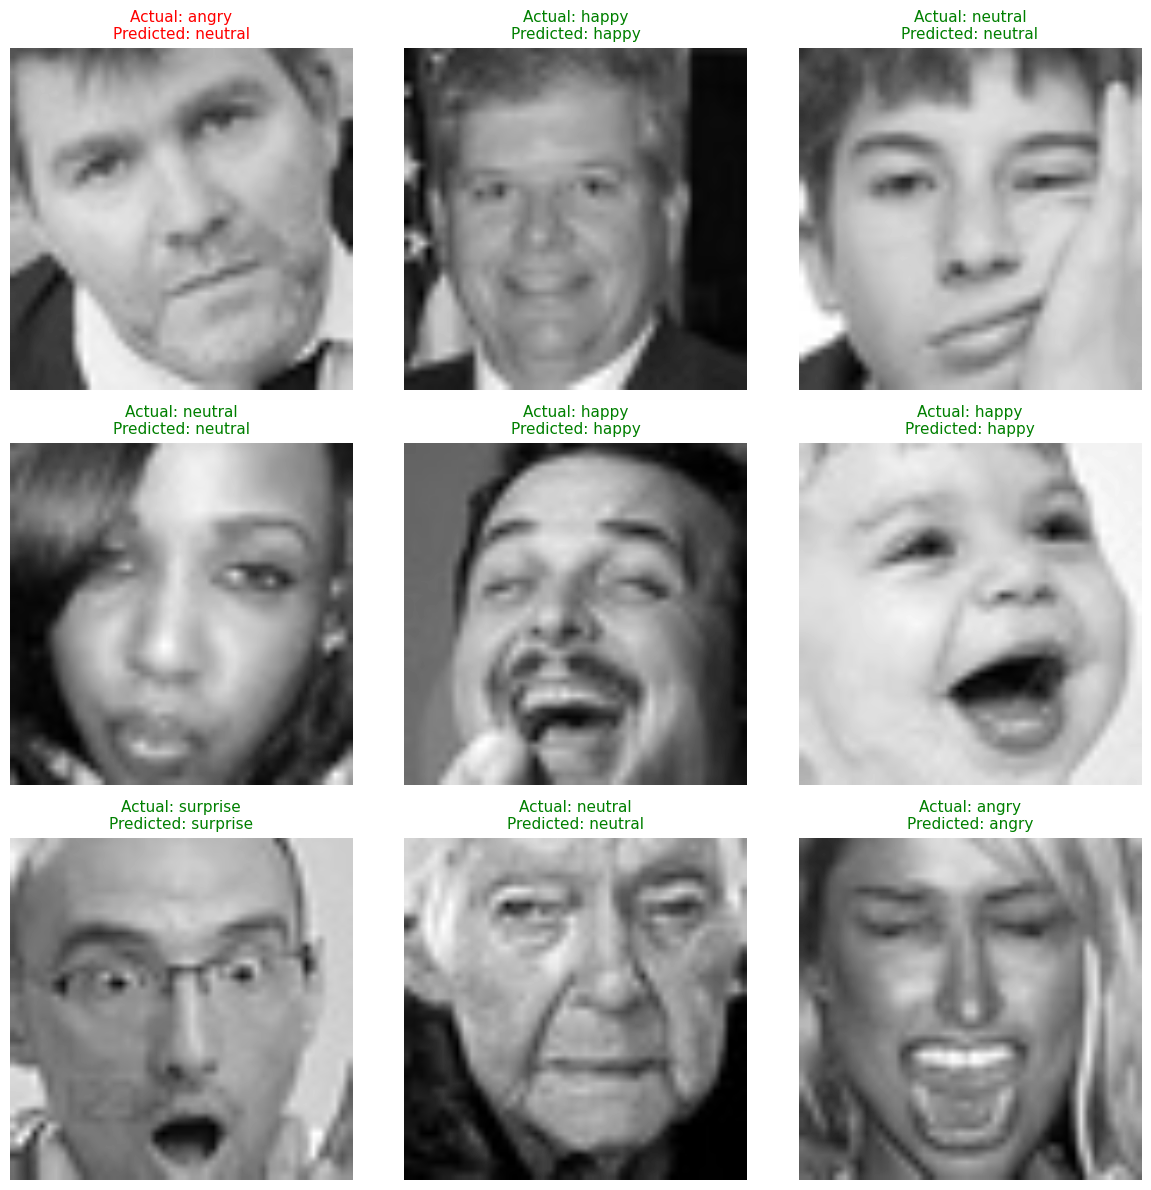

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Pick 9 random images spread across the whole validation set
# (not just the first sequential batch, which was all one class)
filepaths = val_generator.filepaths
true_labels = val_generator.classes

np.random.seed(None)
random_indices = np.random.choice(len(filepaths), size=9, replace=False)

plt.figure(figsize=(12,12))

for plot_i, idx in enumerate(random_indices):
    img = Image.open(filepaths[idx]).convert("L").resize((48,48))
    img_array = np.array(img) / 255.0
    img_input = img_array.reshape(1,48,48,1)

    pred = model.predict(img_input, verbose=0)
    predicted_class = class_names[np.argmax(pred)]
    actual_class = class_names[true_labels[idx]]
    correct = predicted_class == actual_class

    plt.subplot(3, 3, plot_i+1)
    plt.imshow(img_array, cmap='gray', interpolation='bilinear')
    plt.title(
        f"Actual: {actual_class}\nPredicted: {predicted_class}",
        fontsize=11,
        color=("green" if correct else "red")
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


<h2 style="color:#166534;">
💾 Saving the Trained CNN Model
</h2>

In [30]:
model.save("FER2013_CNN_Model.h5")

print("Model saved successfully!")


Model saved successfully!


<h2 style="color:#2E8B57;">Conclusion</h2>

<p style="font-size:16px; line-height:1.8; text-align:justify;">
In this project, the <b>FER2013</b> dataset was analyzed using
<b>Exploratory Data Analysis (EDA)</b> to understand the distribution of
different facial emotion classes, image dimensions, and pixel intensity values.
The dataset was then preprocessed through normalization, label encoding, and
data splitting to prepare it for training.
</p>

<p style="font-size:16px; line-height:1.8; text-align:justify;">
A <b>Convolutional Neural Network (CNN)</b> model was developed to classify
seven different facial emotions. The model was evaluated using training and
validation accuracy, loss curves, a confusion matrix, and a classification
report. The results demonstrate that the CNN model is capable of recognizing
facial emotions with good performance.
</p>

<p style="font-size:16px; line-height:1.8; text-align:justify;">
Overall, this project highlights the effectiveness of deep learning in facial
emotion recognition and provides a strong foundation for real-world applications
such as healthcare, human-computer interaction, smart surveillance, and
emotion-aware systems.
</p>